# Supplementary visualization for MCMC chains

Date: 08/28/2026


This jupyter notebook first create several subplots, and then combine them together at the end for a complete figure. Please adjust the figure dimension based on your own study area.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import xarray as xr
import os
import scipy as sp

## 1. Config 

Change to your own paths. Each section is expected to run sequentially (e.g. section 3.3 depends on the data loaded in section 3.2)


In [2]:
# ------------------------------------------------------------------
# CONFIGURATIONS (CHANGE THIS)
# ------------------------------------------------------------------

GLACIER_NAME = "Thwaites"     # used in plot titles
RESOLUTION   = 500                # grid resolution (m), shared by all sections
RNG_SEED     = 23198104
CSV_PATH       = "/blue/emackie/niyashao/DMG/Thwaites/ThwaitesDataGridded2.csv"

# ------------------------------------------------------------------
# 3.1. Location of the glacier
# ------------------------------------------------------------------

GROUNDING_LINE_SHP_PATH = './moa2014_groundingline_v01/moa2014_grounding_line_v01.shp'

# ------------------------------------------------------------------
# 3.2. Loss
# ------------------------------------------------------------------

SEED_FILE_PATH = Path(r'/blue/emackie/niyashao/DMG/200_seeds.txt')
# the indicies of the large scale chains you want to plot for
# only change it when you do not have results from all 10 LSCs
LSC_INDICIES = list(range(0,10))
REALIZATION_INDICIES = [10, 20, 30]
SIGMA_MC = 7

# ------------------------------------------------------------------
# 3.3 — ensemble statistics
# load 100 beds, ensemble mean, ensemble std, 3 realizations
# ------------------------------------------------------------------

LOSS_LSC_FOLDER = Path("/blue/emackie/niyashao/results/LargeScaleChain/")
LOSS_SSC_FINAL_ITER = "40k"
MAX_STD = 200 #maximum standard deviation in the plot

# ------------------------------------------------------------------
# 3.4 — variogram check for one realization
# ------------------------------------------------------------------

SGS_BED_PATH        = "/blue/emackie/niyashao/DMG/Thwaites/Thwaites_sgs_bed_0.txt"
VARIOGRAM_TREND_LSC_BED_PATH = "/blue/emackie/niyashao/results/LargeScaleChain/157654/bed_10000k.npy"

VARIOGRAM_SAMPLES = 0.15          # fraction of points to subsample; start small (0.05) to sanity check fast
VARIOGRAM_SAMPLES_RADAR = 0.6    # same as VARIOGRAM_SAMPLES but used for conditioning radar data: they are sparser than a complete topography map
VARIOGRAM_MODEL    = 'matern'
VARIOGRAM_MAXLAG   = 20_000
VARIOGRAM_NLAGS    = 80
VARIOGRAM_DETREND  = True
VARIOGRAM_TREND_LSC_BED_PATH = "/blue/emackie/niyashao/results/LargeScaleChain/157654/bed_10000k.npy"

# ------------------------------------------------------------------
# 4. Additional checks
# ------------------------------------------------------------------

RADAR_THICKNESS_PATH = "/mnt/f/DataForStudy/DEMOGORGN_data/bedmap3_raw_thick_compilation.npy"
LSC_SINGLE_BED_PATH = "/blue/emackie/niyashao/results/LargeScaleChain/157654/bed_9930k.npy"          # single realization, .txt or .npy
SSC_SINGLE_BED_PATH = "/blue/emackie/niyashao/results/LargeScaleChain/157654/SmallScaleChain/128105/bed_20k.npy"          # single realization, .txt or .npy

In [3]:
plt.rcParams['font.family'] = 'sans-serif'

# 2. load consistent colormaps

In [4]:
from matplotlib.colors import ListedColormap

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = matplotlib.colors.LinearSegmentedColormap.from_list('trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),cmap(np.linspace(minval, maxval, n)))
    return new_cmap

def load_cmp_divergent():
    #green_pink
    N = 128
    vals1 = np.ones((N, 4))
    vals1[:, 0] = np.linspace(65/256, 1, N)
    vals1[:, 1] = np.linspace(97/256, 1, N)
    vals1[:, 2] = np.linspace(10/256, 1, N)
    vals2 = np.ones((N, 4))
    vals2[:, 0] = np.linspace(1,153/256, N)
    vals2[:, 1] = np.linspace(1,12/256, N)
    vals2[:, 2] = np.linspace(1,122/256, N)
    cmp_armyrose = ListedColormap(np.vstack([vals1,vals2]))

    #green_brown
    N = 128
    vals1 = np.ones((N, 4))
    vals1[:, 0] = np.linspace(1/256, 1, N)
    vals1[:, 1] = np.linspace(133/256, 1, N)
    vals1[:, 2] = np.linspace(113/256, 1, N)
    vals2 = np.ones((N, 4))
    vals2[:, 0] = np.linspace(1,166/256, N)
    vals2[:, 1] = np.linspace(1,97/256, N)
    vals2[:, 2] = np.linspace(1,26/256, N)  
    cmp_gnbr = ListedColormap(np.vstack([vals1,vals2]))

    #purple_pink
    N = 128
    vals1 = np.ones((N, 4))
    vals1[:, 0] = np.linspace(58/256, 1, N)
    vals1[:, 1] = np.linspace(40/256, 1, N)
    vals1[:, 2] = np.linspace(191/256, 1, N)
    vals2 = np.ones((N, 4))
    vals2[:, 0] = np.linspace(1,191/256, N)
    vals2[:, 1] = np.linspace(1,38/256, N)
    vals2[:, 2] = np.linspace(1,163/256, N)
    cmp_prpi = ListedColormap(np.vstack([vals1,vals2]))

    #purple_orange
    N = 128
    vals1 = np.ones((N, 4))
    vals1[:, 0] = np.linspace(1, 179/256, N)
    vals1[:, 1] = np.linspace(1, 88/256, N)
    vals1[:, 2] = np.linspace(1, 6/256, N)
    vals2 = np.ones((N, 4))
    vals2[:, 0] = np.linspace(84/256, 1, N)
    vals2[:, 1] = np.linspace(39/256, 1, N)
    vals2[:, 2] = np.linspace(136/256, 1, N)
    cmp_pror = ListedColormap(np.vstack([vals2,vals1]))

    return cmp_armyrose, cmp_gnbr, cmp_prpi, cmp_pror

def load_cmp_linear():
    #mint
    N = 128
    vals1 = np.ones((N, 4))
    vals1[:, 0] = np.linspace(215/256, 18/256, N)
    vals1[:, 1] = np.linspace(256/256, 63/256, N)
    vals1[:, 2] = np.linspace(220/256, 90/256, N)
    cmp_mint = ListedColormap(vals1)

    #light green
    N = 128
    vals1 = np.ones((N, 4))
    vals1[:, 0] = np.linspace(82/256, 256/256, N)
    vals1[:, 1] = np.linspace(163/256, 256/256, N)
    vals1[:, 2] = np.linspace(92/256, 256/256, N)
    cmp_lightgreen = ListedColormap(vals1)

    cmap = plt.get_cmap('magma')
    cmp_magma = matplotlib.colors.LinearSegmentedColormap.from_list('magma',cmap(np.linspace(0.3, 1, 256)))

    cmap = plt.get_cmap('gist_earth')
    cmp_earth = truncate_colormap(cmap, 0, 0.9)

    N=100
    vals = np.ones((N, 4))
    vals[:, 0] = np.linspace(129/256, 1, N)
    vals[:, 1] = np.linspace(212/256, 1, N)
    vals[:, 2] = np.linspace(250/256, 1, N)
    cmp_lightblue = ListedColormap(vals)

    N=100
    vals = np.ones((N, 4))
    vals[:, 0] = np.linspace(30/256, 1, N)
    vals[:, 1] = np.linspace(136/256, 1, N)
    vals[:, 2] = np.linspace(229/256, 1, N)
    cmp_mediumblue = ListedColormap(vals)

    N = 128
    vals1 = np.ones((N, 4))
    vals1[:, 0] = np.linspace(1, 50/256, N)
    vals1[:, 1] = np.linspace(1, 50/256, N)
    vals1[:, 2] = np.linspace(1, 50/256, N)
    cmp_lightgrey = ListedColormap(vals1)

    return cmp_mint, cmp_lightgreen, cmp_magma, cmp_earth, cmp_lightblue, cmp_mediumblue, cmp_lightgrey

In [5]:
cmp_armyrose, cmp_gnbr, cmp_prpi, cmp_pror = load_cmp_divergent()
cmp_mint, cmp_lightgreen, cmp_magma, cmp_earth, cmp_lightblue, cmp_mediumblue, cmp_lightgrey = load_cmp_linear()

# 3 figures for reporting in paper

## 3.1 Location of the glacier

In [6]:
import matplotlib.patches as patches
import geopandas as gpd

In [7]:
df_map = pd.read_csv(CSV_PATH)
min_x, max_x = np.min(df_map['x']), np.max(df_map['x'])
min_y, max_y = np.min(df_map['y']), np.max(df_map['y'])

__Please unzip moa2014 zip file and do not delete any files in the zip folder__

In [8]:
# load grounding line for Antarctic Ice Sheet
gl = gpd.read_file(GROUNDING_LINE_SHP_PATH)
glx,gly = gl.geometry[0].exterior.xy

ERROR 1: PROJ: proj_create_from_database: Open of /blue/emackie/niyashao/conda/envs/gstatsnew/share/proj failed


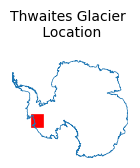

In [9]:
plt.figure(figsize=(1.5,1.5))
plt.plot(glx,gly,linewidth=0.5)
rect = patches.Rectangle((min_x, min_y), max_x-min_x, max_y-min_y, linewidth=0.5, edgecolor='r', facecolor='r')
plt.gca().add_patch(rect)
plt.gca().axis('off')
plt.gca().margins(0, 0)
plt.axis('scaled')
plt.title(GLACIER_NAME + ' Glacier \n Location',fontsize=10)
plt.savefig('glacier_location.png',dpi=600,bbox_inches='tight')

## 3.2 Losses

Load mass-flux-residual loss for BedMachine and for iterations through large-scale and small-scale chains

In [10]:
df = pd.read_csv(CSV_PATH)

x_uniq = np.unique(df.x)
y_uniq = np.unique(df.y)
xx, yy = np.meshgrid(x_uniq, y_uniq)

In [11]:
dhdt = df['dhdt'].values.reshape(xx.shape)
smb = df['smb'].values.reshape(xx.shape)
velx = df['velx'].values.reshape(xx.shape)
vely = df['vely'].values.reshape(xx.shape)

bedmap_mask = df['bedmap_mask'].values.reshape(xx.shape)
surf = df['bedmap_surf'].values.reshape(xx.shape)
bedmap_bed = df['bedmap_bed'].values.reshape(xx.shape)

bedmachine_bed = df['bedmachine_bed'].values.reshape(xx.shape)
bedmachine_source = df['bedmachine_source'].values.reshape(xx.shape)

highvel_mask = df['highvel_mask'].values.reshape(xx.shape)

In [12]:
def get_mass_flux_residual(bed, surf, velx, vely, dhdt, smb, resolution):
    thick = surf - bed

    dx = np.gradient(velx * thick, resolution, axis=1)
    dy = np.gradient(vely * thick, resolution, axis=0)

    res = dx + dy + dhdt - smb
    return res


def calculate_loss(mass_flux_residuals, highvel_region, sigma_mc):
    return np.nansum(np.square(mass_flux_residuals[highvel_region == 1])) / (2 * sigma_mc ** 2)

In [13]:
# loss for BedMachine topography — this becomes our reference line for the overlay plot below,
# computed from your data instead of a hardcoded number from someone else's glacier
bedmachine_mass_flux_residuals = get_mass_flux_residual(bedmachine_bed, surf, velx, vely, dhdt, smb, RESOLUTION)
bedmachine_loss = calculate_loss(bedmachine_mass_flux_residuals, highvel_mask, SIGMA_MC)
bedmachine_loss

566852.2135856802

Walk through LargeScaleChain and SmallScaleChain folders while finding the location of results_niterk.npy files

In [14]:
def load_ensemble_fileinfo(seed_file_path, lsc_folder, ssc_final_iter, lsc_indices=list(range(0,10))):
    
    with open(seed_file_path, 'r') as f:
        rng_seeds = [int(line.strip()) for line in f.readlines()]

    chainTrack = {}
    
    # find all ssc beds based on lsc indices
    for lsc_idx in lsc_indices:
        lsc_seed = rng_seeds[lsc_idx]
        lsc_path = lsc_folder / str(lsc_seed)[:6]
        lsc_npz_path = list(lsc_path.glob("results_*k.npz"))
        if not lsc_path or not lsc_path.exists():
             print('Warning: the large scale chain do not have results_nk.npz')
        else:
            lsc_npz_path = lsc_npz_path[0]

        chainTrack[lsc_seed] = {
            'lsc_loss_file': lsc_npz_path,
            'ssc_chains': {}
        }
        
        ssc_seeds_for_lsc = rng_seeds[
            10 + lsc_idx * 10 :
            10 + lsc_idx * 10 + 10
        ]
        for i, ssc_seed in enumerate(ssc_seeds_for_lsc):
            ssc_path = lsc_folder / str(lsc_seed)[:6] / 'SmallScaleChain' / str(ssc_seed)[:6]

            if not os.path.exists(ssc_path):
                print('Warning: file path specified for small scale chain does not exist')
                break
            else:
                bed_filename = 'bed_' + ssc_final_iter + '.npy'
                
                ssc_npz = list(ssc_path.glob("results_*k.npz"))
                ssc_npz_path = ssc_npz[0] if ssc_npz else None

                init_iter_path = ssc_path / 'init_iter.txt'
                if init_iter_path.exists():
                    init_iter_val = int(np.loadtxt(init_iter_path))
                else:
                    print('Warning: Small Scale Chain do not contain init_iter.txt')
                
                chainTrack[lsc_seed]['ssc_chains'][ssc_seed] = {
                    'ssc_loss_file': ssc_path / ssc_npz_path,
                    'ssc_final_bed_file': ssc_path / bed_filename,
                    'init_iter': init_iter_val
                }
        
    return chainTrack

In [15]:
chainTrack = load_ensemble_fileinfo(SEED_FILE_PATH, LOSS_LSC_FOLDER, LOSS_SSC_FINAL_ITER, lsc_indices=LSC_INDICIES)

In [16]:
# # --- Verification ---
# for lsc, data in chainTrack.items():
#     print(f"LARGE CHAIN SEED: {lsc}")
#     print(f"  LSC loss -> {data['lsc_loss_file']}")
#     if not data['ssc_chains']:
#         print("  (No Small Scale Chains found)")
#     for ssc, ssc_info in data['ssc_chains'].items():
#         print(f"    SMALL CHAIN SEED: {ssc}")
#         print(f"      SSC loss     -> {ssc_info['ssc_loss_file']}")
#         print(f"      SSC bed     -> {ssc_info['ssc_final_bed_file']}")
#         print(f"      Initial Iter -> {ssc_info['init_iter']}")
#     print("-" * 40)

In [17]:
def load_ensemble(chainTrack):

    all_chains_data = []
    
    for lsc_seed, track_data in chainTrack.items():
        print(f"Processing Large Chain Seed: {lsc_seed}...")
    
        lsc_loss = track_data['lsc_loss_file']
        with np.load(lsc_loss) as lsc_loss:
            lsc_loss = lsc_loss[lsc_loss.files[0]]

        #return(track_data['ssc_chains'])
        
        small_chains_data = []
        for ssc_seed, ssc_info in track_data['ssc_chains'].items():
            #print(ssc_seed)
            
            ssc_loss = ssc_info['ssc_loss_file']
            ssc_bed = ssc_info['ssc_final_bed_file']
            init_iter = ssc_info['init_iter']

            #print(ssc_loss, ssc_bed, init_iter)
            
            with np.load(ssc_loss) as ssc_loss:
                ssc_loss = ssc_loss[ssc_loss.files[0]]
            ssc_bed = np.load(ssc_bed)
            # dynamic offset: LSC total length minus the SSC starting point
            dynamic_offset = len(lsc_loss) - init_iter
    
            small_chains_data.append({
                'loss': ssc_loss,
                'bed': ssc_bed,
                'offset': dynamic_offset,
                'label': f'SSC {ssc_seed}'
            })
    
        all_chains_data.append({
            'lsc_loss': lsc_loss,
            'lsc_label': f'LSC {lsc_seed}',
            'sscs': small_chains_data
        })

    print("Data extraction complete! Ready to plot.")
    return all_chains_data

In [18]:
all_chains_data = load_ensemble(chainTrack)

Processing Large Chain Seed: 157654094873578629529035999554256708511...
Processing Large Chain Seed: 65480343372422548043707933219776006261...
Processing Large Chain Seed: 125068026375670843255103524882208013818...
Processing Large Chain Seed: 8218613749787734244643222434109388970...
Processing Large Chain Seed: 315470399564675134671880023850770077997...
Processing Large Chain Seed: 209073225993367578900513735398547396433...
Processing Large Chain Seed: 97396032662263410186312305914597411447...
Processing Large Chain Seed: 84200212033853570211731781765681254177...
Processing Large Chain Seed: 165589946500619179339219402465704060780...
Processing Large Chain Seed: 271381301624103247709389477373024237531...
Data extraction complete! Ready to plot.


In [19]:
def plot_all_loss_chains(all_chains_data, ref_loss, save_path=None, show_plot=True, legend=False):
    """Plot multiple Large Scale Chains and their respective Small Scale Chains on one graph."""
    if not all_chains_data:
        print("Error: No data provided to plot.")
        return

    fig, ax = plt.subplots(figsize=(85/25.4, 80/25.4))
    colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(all_chains_data))))

    for idx, chain_group in enumerate(all_chains_data):
        lsc_loss = chain_group['lsc_loss']
        lsc_label = chain_group['lsc_label']
        sscs = chain_group['sscs']

        base_color = 'blue'
        x_large = np.arange(0, len(lsc_loss))

        ax.plot(x_large[::100], lsc_loss[::100], c=base_color, linewidth=1, alpha=0.9)

        for ssc in sscs:
            loss_arr = ssc['loss']
            offset = ssc['offset']
            label = ssc['label']

            start_idx = max(0, len(lsc_loss) - offset)
            x_small = np.arange(start_idx, start_idx + len(loss_arr))

            #print(x_small,loss_arr)

            ax.plot(x_small[::100], loss_arr[::100], c='grey', linewidth=1, alpha=0.8, 
                    linestyle='--')

    ax.plot(x_large[::100], lsc_loss[::100], c=base_color, label='large-scale chains', 
            linewidth=1, alpha=0.9)
    ax.plot(x_small[::100], loss_arr[::100], c='grey', label='small-scale chains',
            linewidth=1, alpha=0.8, linestyle='--')

    ax.axhline(ref_loss, ls=':', c='red', linewidth=2, label='BedMachine')

    ax.set_xlabel("Total Iterations", fontsize=10)
    ax.set_ylabel("Loss ($m^2/yr$)", fontsize=10)
    ax.set_title(f"Mass Conservation Loss", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)
    if legend:
        ax.legend(loc='upper right', fontsize=10)
    
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")

    if show_plot:
        plt.show()
        
    plt.close()

Plot saved to: all_chains_overlay.png


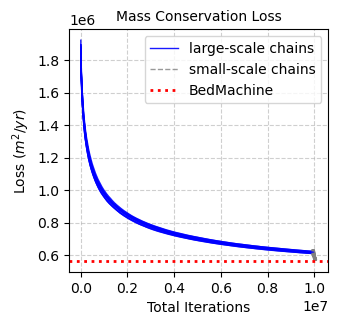

In [20]:
#for i, eachChain in enumerate(all_chains_data):
    # Notice the removed leading slash below
#save_path = f"losses/chain_{i}__overlay.png"
#    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    
    # Pass show_plot=False so the loop runs continuously in the background
#plot_all_loss_chains(all_chains_data, ref_loss=bedmachine_loss, save_path=save_path, show_plot=False)

#print("All individual chain plots saved successfully!")

# 3. Your final overall plot
plot_all_loss_chains(all_chains_data, ref_loss=bedmachine_loss, save_path="all_chains_overlay.png", show_plot=True, legend=True)

In [21]:
def plot_all_loss_chains_zoomin(all_chains_data, ref_loss, save_path=None, show_plot=True, legend=False):
    """Plot multiple Large Scale Chains and their respective Small Scale Chains on one graph."""
    if not all_chains_data:
        print("Error: No data provided to plot.")
        return

    fig, ax = plt.subplots(figsize=(85/25.4, 80/25.4))
    colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(all_chains_data))))

    for idx, chain_group in enumerate(all_chains_data):
        lsc_loss = chain_group['lsc_loss']
        lsc_label = chain_group['lsc_label']
        sscs = chain_group['sscs']

        base_color = 'blue'
        x_large = np.arange(0, len(lsc_loss))

        ax.plot(x_large[::100], lsc_loss[::100], c=base_color, linewidth=1, alpha=0.9)

        min_loss = lsc_loss[0]
        max_loss = 0
        
        for ssc in sscs:
            loss_arr = ssc['loss']
            offset = ssc['offset']
            label = ssc['label']

            start_idx = max(0, len(lsc_loss) - offset)
            x_small = np.arange(start_idx, start_idx + len(loss_arr))

            ax.plot(x_small[::100], loss_arr[::100], c='grey', linewidth=1, alpha=0.8, 
                    linestyle='--')

            min_loss = np.min((np.min(loss_arr),min_loss))
            max_loss = np.max((np.max(loss_arr),max_loss))

    ax.plot(x_large[::100], lsc_loss[::100], c=base_color, label='large-scale chains', 
            linewidth=1, alpha=0.9)
    ax.plot(x_small[::100], loss_arr[::100], c='grey', label='small-scale chains',
            linewidth=1, alpha=0.8, linestyle='--')

    ax.axhline(ref_loss, ls=':', c='red', linewidth=2, label='BedMachine')

    ax.set_xlabel("Total Iterations", fontsize=10)
    ax.set_ylabel("Loss ($m^2/yr$)", fontsize=10)
    ax.set_title(f"Mass Conservation Loss", fontsize=10)
    #ax.grid(True, linestyle='--', alpha=0.6)
    if legend:
        ax.legend(loc='upper right', fontsize=10)
        
    ax.set_xlim(len(lsc_loss) - offset*10 - 500000, len(lsc_loss) + len(loss_arr) + 500000)
    ax.set_ylim(min_loss - ((max_loss-min_loss)*0.1), max_loss + ((max_loss-min_loss)*0.1))
    
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")

    if show_plot:
        plt.show()
        
    plt.close()

Plot saved to: all_chains_overlay_zoomin.png


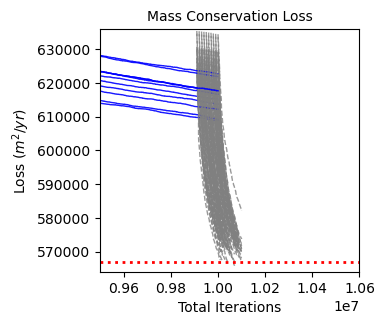

In [22]:
plot_all_loss_chains_zoomin(all_chains_data, ref_loss=bedmachine_loss, save_path="all_chains_overlay_zoomin.png", show_plot=True, legend=False)

## 3.3 Ensemble mean, standard deviations, and three realizations

Load the ensemble of beds from the dataset loaded in the last subsection. Plot ensemble mean and standard deviations

In [23]:
# load an ensemble of bed from the dataset
bed_list = []
for lsc in all_chains_data:
    for ssc in lsc['sscs']:
        bed_list.append(ssc['bed'])
bed_ensemble = np.array(bed_list)

In [24]:
# create a grid of x and y coordinates (use your coordinates from T1)
xmin = np.min(df.x)
xmax = np.max(df.x) + RESOLUTION
ymin = np.min(df.y)
ymax = np.max(df.y) + RESOLUTION

xx, yy = np.meshgrid(np.arange(xmin, xmax, RESOLUTION), 
                     np.arange(ymin, ymax, RESOLUTION))

In [25]:
bed_ensemble.shape

(100, 1200, 1060)

In [26]:
## Used for saving to matlab readable file
# bed_ensemble_save = np.concatenate(([yy], bed_ensemble), axis=0)
# bed_ensemble_save = np.concatenate(([xx], bed_ensemble_save), axis=0)
# sp.io.savemat('Thwaites_mcmc_ensemble_100.mat', {'topography': bed_ensemble_save})

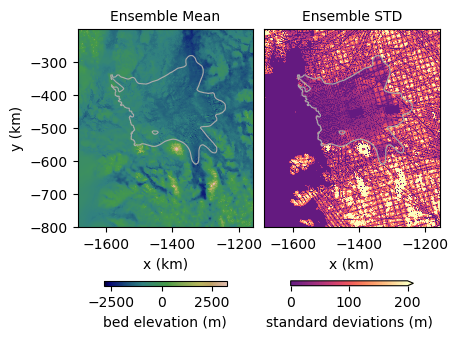

In [27]:
#############################layout###################################

#Plot data
mm = 1/25.4
length = 179*2/3*mm
height = length / xx.shape[0] / 2 * xx.shape[1] + (40*mm)

fig = plt.figure(figsize=(length, height))

gs = fig.add_gridspec(1,2,width_ratios=[1,1])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

#############################ax1###################################

f_mean = ax1.pcolormesh(xx/1000, yy/1000, np.mean(bed_ensemble[:,:,:],axis=0),cmap=cmp_earth)
ax1.contour(xx/1000, yy/1000, highvel_mask, levels=[0.5], colors='darkgrey', linewidths=0.8)
ax1.set_ylabel('y (km)',fontsize=10)
ax1.set_xlabel('x (km)',fontsize=10)
ax1.set_title('Ensemble Mean',fontsize=10)
cbar1 = plt.colorbar(f_mean,ax=ax1,aspect=25,orientation='horizontal',
             location='bottom',pad=0.1,shrink=0.7)
cbar1.set_label(label='bed elevation (m)',fontsize=10)
cbar1.ax.tick_params(axis='both')
ax1.axis('scaled')

#############################ax2###################################

f_std = ax2.pcolormesh(xx/1000, yy/1000, np.std(bed_ensemble[:,:,:],axis=0),cmap=cmp_magma,vmax=MAX_STD)
ax2.contour(xx/1000, yy/1000, highvel_mask, levels=[0.5], colors='darkgrey', linewidths=0.8)
ax2.set_xlabel('x (km)',fontsize=10)
ax2.set_yticks([])
ax2.set_title('Ensemble STD',fontsize=10)
cbar2 = plt.colorbar(f_std,ax=ax2,aspect=25,orientation='horizontal',
             location='bottom',pad=0.1,shrink=0.7,extend='max')
cbar2.set_label(label='standard deviations (m)',fontsize=10)
cbar2.ax.tick_params(axis='both')
ax2.axis('scaled')

plt.tight_layout(w_pad=0.1,h_pad=0.1)

plt.savefig('ensemble_stats.png',dpi=600,bbox_inches='tight')

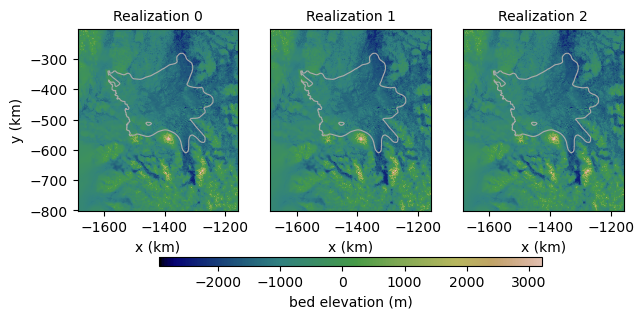

In [28]:
#############################layout###################################

#Plot data
mm = 1/25.4

length = 179*mm
height = (length) / 3 / xx.shape[1] * xx.shape[0] + (35*mm)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(length, height))
indexes = REALIZATION_INDICIES

for i, ax in enumerate(axes):
    f_topo = ax.pcolormesh(xx/1000, yy/1000, bed_ensemble[int(indexes[i]),:,:], cmap=cmp_earth)
    ax.contour(xx/1000, yy/1000, highvel_mask, levels=[0.5], colors='darkgrey', linewidths=0.8)
    if i == 0:
        ax.set_ylabel('y (km)',fontsize=10)
    else:
        ax.set_yticks([])
    ax.set_xlabel('x (km)',fontsize=10)
    ax.set_title('Realization ' + str(i),fontsize=10)
    ax.axis('scaled')
    
cbar = fig.colorbar(f_topo, ax=axes, aspect=45, orientation='horizontal',
                   location='bottom', shrink=0.7)
cbar.set_label(label='bed elevation (m)',fontsize=10)

plt.savefig('realizations.png',dpi=600,bbox_inches='tight')

## 3.4 Isotropic experimental variograms

Computes the experimental variogram for one small-scale chain realization, overlay with variogram for radar measurements, variogram for bedmachine, and variogram for bedmap

In [29]:
# section-specific imports (only needed here)
from sklearn.preprocessing import QuantileTransformer
import skgstat as skg

In [30]:
df = pd.read_csv(CSV_PATH)

x_uniq = np.unique(df.x)
y_uniq = np.unique(df.y)

xx_var, yy_var = np.meshgrid(x_uniq, y_uniq)

dhdt_var               = df['dhdt'].values.reshape(xx_var.shape)
smb_var                = df['smb'].values.reshape(xx_var.shape)
velx_var               = df['velx'].values.reshape(xx_var.shape)
vely_var               = df['vely'].values.reshape(xx_var.shape)
bedmap_mask_var         = df['bedmap_mask'].values.reshape(xx_var.shape)
bedmachine_thickness_var = df['bedmachine_thickness'].values.reshape(xx_var.shape)
bedmap_surf_var         = df['bedmap_surf'].values.reshape(xx_var.shape)
highvel_mask_var        = df['highvel_mask'].values.reshape(xx_var.shape)
bedmap_bed_var          = df['bedmap_bed'].values.reshape(xx_var.shape)

Fetch all bed files that end with `.npy`.

In [31]:
def _load_bed(path):
    path = str(path)
    return np.load(path) if path.endswith('.npy') else np.loadtxt(path)

ssc_bed = _load_bed(SSC_SINGLE_BED_PATH)
bedmachine_bed = bedmap_surf_var - bedmachine_thickness_var
bedmap_bed = bedmap_bed_var

compute nst_trans used for normalizing bed elevation

In [32]:
cond_bed_var = np.where(bedmap_mask_var == 1, df['bed'].values.reshape(xx_var.shape), bedmap_bed_var)
df['cond_bed'] = cond_bed_var.flatten()

if VARIOGRAM_DETREND:
    # calculating trend
    lsc_bed = _load_bed(VARIOGRAM_TREND_LSC_BED_PATH)
    variogram_trend = sp.ndimage.gaussian_filter(lsc_bed, sigma=10)
    print(np.max(variogram_trend),np.mean(variogram_trend),np.std(variogram_trend),np.min(variogram_trend))

    # normalize the detrended conditioning bed data
    data = (df['cond_bed'] - variogram_trend.flatten()).values.reshape(-1,1)
    nst_trans = QuantileTransformer(n_quantiles=500, output_distribution="normal",random_state=RNG_SEED).fit(data)
    
else:
    # normalize the conditioning bed data
    data = df['cond_bed'].values.reshape(-1, 1)
    nst_trans = QuantileTransformer(n_quantiles=500, output_distribution="normal", random_state=RNG_SEED).fit(data)

2165.237059927941 -794.0840488541436 477.8675170074197 -2143.082358002169


Compute variogram for simulated bed & conditioning bed. Same method, different input array.

In [33]:
def _variogram_for_bed(df: pd.DataFrame,
                        bed_flat: np.ndarray,
                        samples: float = 0.4,
                        random_state: int = 42,
                        model: str = 'matern',
                        maxlag: int = 80_000,
                        n_lags: int = 50,
                        nst_trans: bool = False):
    
    """Pass in a FLATTENED bed array. Returns (bins, experimental) for one simulated bed."""
    df = df.copy()
    if nst_trans != False:
        df['simulated_topography'] = nst_trans.transform(bed_flat.reshape((-1,1)))
    else:
        df['simulated_topography'] = bed_flat

    df_sim = df.sample(frac=samples, random_state=random_state)
    df_sim = df_sim[df_sim['simulated_topography'].notnull()]
    df_sim = df_sim[df_sim['highvel_mask'] == 1]

    V = skg.Variogram(df_sim[['x', 'y']].values,
                       df_sim['simulated_topography'],
                       bin_func='even', n_lags=n_lags, maxlag=maxlag,
                       normalize=False, model=model, samples=0.6)
    return V.bins, V.experimental


def _variogram_radar(df: pd.DataFrame,
                      samples: float = 0.9,
                      random_state: int = 42,
                      model: str = 'matern',
                      maxlag: int = 80_000,
                      n_lags: int = 30,
                      nst_trans: bool = False):
    
    """Return (bins, experimental) for the radar / conditioning bed."""
    df_v = df.copy()
    if nst_trans != False:
        cond_bed = df_v['cond_bed'].values.reshape((-1,1))
        df_v['cond_bed'] = nst_trans.transform(cond_bed)
    
    df_v = df_v.sample(frac=samples, random_state=random_state)
    df_v = df_v[df_v['cond_bed'].notnull()]
    df_v = df_v[df_v['bedmap_mask'] == 1]

    V = skg.Variogram(df_v[['x', 'y']].values,
                       df_v['cond_bed'],
                       bin_func='even', n_lags=n_lags, maxlag=maxlag,
                       normalize=False, model=model)
    
    return V.bins, V.experimental

Put everything together and plot.

In [34]:
def compute_variogram_single_bed(df: pd.DataFrame,
                                 small_scale_chain_bed: np.ndarray,
                                 bedmachine_bed = None,
                                 bedmap_bed = None,
                                 detrend = False,
                                 samples: float = 0.4,
                                 samples_radar: float = 0.9,
                                 random_state: int = 42,
                                 model: str = 'matern',
                                 maxlag: int = 80_000,
                                 n_lags: int = 30,
                                 figsize: tuple = (120/25.4, 80/25.4)):
    """
    For every seed folder in `folder_path`: load each .npy bed, compute its experimental
    variogram, plot with a colour unique to that seed. Also plots the radar-measurement
    variogram in black.
    """
    df_vario = df.copy()

    if detrend:
        #datacoord = df[df['cond_bed'].notnull()][['x','y']].values
        #dataval = df[df['cond_bed'].notnull()][['cond_bed']].values
        #variogram_trend = sp.interpolate.RBFInterpolator(datacoord, dataval, kernel='thin_plate_spline',smoothing=5e10,neighbors=250)(np.stack([df.x, df.y]).T)
        #variogram_trend = variogram_trend.reshape(small_scale_chain_bed.shape)
        #print('calculated trend by interpolating radar measurements, where trend\'s maximum, mean, and minimum bed elevation as follows: ', np.max(variogram_trend),np.mean(variogram_trend),np.min(variogram_trend))
        lsc_bed = _load_bed(VARIOGRAM_TREND_LSC_BED_PATH)
        variogram_trend = sp.ndimage.gaussian_filter(lsc_bed, sigma=10)
    else:
        variogram_trend = np.zeros(small_scale_chain_bed.shape)
    
    fig, ax = plt.subplots(figsize=figsize)

    print("Computing radar variogram...")
    df_vario = df.copy()
    df_vario['cond_bed'] = df_vario['cond_bed'] - variogram_trend.flatten()
    xr_v, yr_v = _variogram_radar(df_vario, samples_radar, random_state, model, maxlag, n_lags, nst_trans)
    ax.scatter(xr_v / 1000, yr_v, s=15, color='black', zorder=5, label='radar measurements')
    
    if bedmachine_bed is not None:
        print("Computing bedmachine variogram...")
        xr_bedmachine, yr_bedmachine = _variogram_for_bed(df, bedmachine_bed.flatten() - variogram_trend.flatten(),
                                                          samples, random_state, model, maxlag, n_lags, nst_trans)
        ax.scatter(xr_bedmachine / 1000, yr_bedmachine, s=15, color='green', zorder=5, label='BedMachine')
    
    if bedmap_bed is not None:
        print("Computing bedmap variogram...")
        xr_bedmap, yr_bedmap = _variogram_for_bed(df, bedmap_bed.flatten() - variogram_trend.flatten(),
                                                  samples, random_state, model, maxlag, n_lags, nst_trans)
        ax.scatter(xr_bedmap / 1000, yr_bedmap, s=15, color='orange', zorder=5, label='Bedmap')

    print("Computing small-scale chain variogram...")
    xr_c, yr_c = _variogram_for_bed(df, small_scale_chain_bed.flatten() - variogram_trend.flatten(),
                                    samples, random_state, model, maxlag, n_lags, nst_trans)
    ax.scatter(xr_c / 1000, yr_c, s=15, color='blue', zorder=5, label='one realization')

    ax.set_title(f'Isotropic Experimental Variogram',fontsize=10)
    ax.set_xlabel('Lag (km)', fontsize=10)
    ax.set_ylabel('Semivariance ($m^2$)', fontsize=10)
    ax.legend(loc='upper left', fontsize=10, markerscale=1.4,
              framealpha=0.85)
    plt.tight_layout()
    plt.savefig('variogram_comparison.png',dpi=600,bbox_inches='tight')


Computing radar variogram...
Computing bedmachine variogram...
Computing bedmap variogram...
Computing small-scale chain variogram...


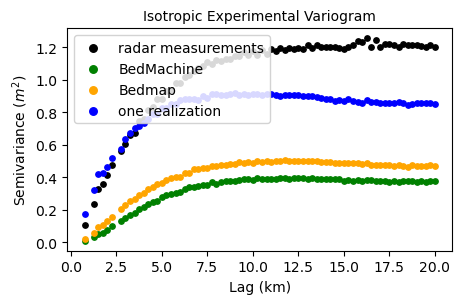

In [35]:
compute_variogram_single_bed(df=df,
                             small_scale_chain_bed = ssc_bed,
                             bedmachine_bed = bedmachine_bed,
                             bedmap_bed = bedmap_bed,
                             detrend=VARIOGRAM_DETREND,
                             samples=VARIOGRAM_SAMPLES,
                             samples_radar=VARIOGRAM_SAMPLES_RADAR,
                             random_state=RNG_SEED,
                             model=VARIOGRAM_MODEL,
                             maxlag=VARIOGRAM_MAXLAG,
                             n_lags=VARIOGRAM_NLAGS)

## 3.5 Combine figures

In [36]:
top_left_path = 'glacier_location.png'
top_right_path = 'ensemble_stats.png'
bottom_left_path = 'all_chains_overlay.png'
bottom_right_path = 'variogram_comparison.png'
bottom_most_path = 'realizations.png'

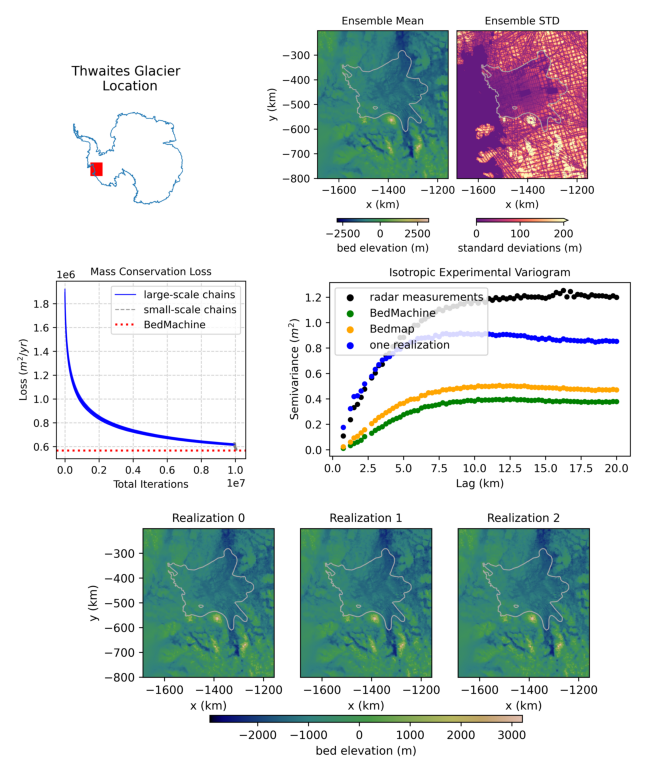

In [37]:
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec

mm = 1/25.4
fig = plt.figure(figsize=(179*mm, 200*mm))

axes = {
    'tl': fig.add_axes([0.12, 0.72, 0.20, 0.20]),
    'tr': fig.add_axes([0.34, 0.66, 0.62, 0.32]),
    'bl': fig.add_axes([0.05, 0.36, 0.35, 0.30]),
    'br': fig.add_axes([0.38, 0.36, 0.62, 0.30]),
    'bm': fig.add_axes([0.05, 0.02, 0.95, 0.33])
}

# read the PNG files 
img_top_left = mpimg.imread(top_left_path)
img_top_right = mpimg.imread(top_right_path)
img_bottom_left = mpimg.imread(bottom_left_path)
img_bottom_right = mpimg.imread(bottom_right_path)
img_bottom_most = mpimg.imread(bottom_most_path)

# display the images
axes['tl'].imshow(img_top_left)
axes['tl'].axis('off')
#axes['tl'].margins(0,0)
axes['tr'].imshow(img_top_right)
axes['tr'].axis('off')
axes['tr'].margins(0,0)
axes['bl'].imshow(img_bottom_left)
axes['bl'].axis('off')
axes['bl'].margins(0,0)
axes['br'].imshow(img_bottom_right)
axes['br'].axis('off')
axes['br'].margins(0,0)
axes['bm'].imshow(img_bottom_most)
axes['bm'].axis('off')
axes['bm'].margins(0,0)

#plt.tight_layout(pad=0)

plt.savefig('figure_combined.png',dpi=600)


# 4. Additional figures for checking validity

## 4.1 Conditioning data check

Sanity check that bed realizations (SGS, large-scale-chain) actually match the conditioning
(radar) data they were supposed to honor. Original author's note: *"we have been encountering
some head-scratching issues related to bed results not matching the conditioning data."*

Data source for radar thickness compilation:
https://www.dropbox.com/scl/fi/uy5o63indt5rgdplumkhx/bedmap3_raw_thick_compilation.npy


In [38]:
# load compiled bed elevation measurements + example realizations
df = pd.read_csv(CSV_PATH)

# most up-to-date conditioning data (full-continent compiled radar thickness)
radar_thickness_full = np.load(RADAR_THICKNESS_PATH)

def _load_bed(path):
    path = str(path)
    return np.load(path) if path.endswith('.npy') else np.loadtxt(path)

sgs = _load_bed(SGS_BED_PATH)
lsc_single = _load_bed(LSC_SINGLE_BED_PATH)
ssc_single = _load_bed(SSC_SINGLE_BED_PATH)

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/f/DataForStudy/DEMOGORGN_data/bedmap3_raw_thick_compilation.npy'

In [ ]:
# create a grid of x and y coordinates (use your coordinates from T1)
xmin = np.min(df.x)
xmax = np.max(df.x) + RESOLUTION
ymin = np.min(df.y)
ymax = np.max(df.y) + RESOLUTION

xx, yy = np.meshgrid(np.arange(xmin, xmax, RESOLUTION), 
                     np.arange(ymin, ymax, RESOLUTION))

In [ ]:
# bounding box of the full compiled Antarctic grid the radar thickness file covers | 
ANT_XMIN, ANT_XMAX = -3333250, 3333250
ANT_YMIN, ANT_YMAX = -3333250, 3333250

# full antarctic grid the compiled radar file is defined on
xx_ant, yy_ant = np.meshgrid(np.arange(ANT_XMIN, ANT_XMAX + RESOLUTION, RESOLUTION),
                              np.arange(ANT_YMIN, ANT_YMAX + RESOLUTION, RESOLUTION))

xmin_ind = np.where(xx_ant == xmin)[1][0]
xmax_ind = np.where(xx_ant == xmax)[1][0]
ymin_ind = np.where(yy_ant == ymin)[0][0]
ymax_ind = np.where(yy_ant == ymax)[0][0]

# crop the full compiled grid down to the study area
radar_thickness = np.flip(radar_thickness_full, axis=0)
radar_thickness = radar_thickness[ymin_ind:ymax_ind, xmin_ind:xmax_ind]

In [ ]:
# unpack dataframe fields needed to build conditioning bed
bedmap_surf            = df['bedmap_surf'].values.reshape(xx.shape)

# conditioning bed = surface - radar-derived thickness
cond_bed = bedmap_surf - radar_thickness

In [ ]:
cond_bed = df['bed'].values.reshape(xx.shape)

Plot data and differences. `GLACIER_NAME` from the config cell drives the title, set it correctly before you interpret this plot.

In [ ]:
# --- Consistent color limits for main fields ---
vmin = np.nanmin([cond_bed, sgs, lsc_single])
vmax = np.nanmax([cond_bed, sgs, lsc_single])

# --- Differences ---
diff_sgs     = cond_bed - sgs
diff_ssc     = cond_bed - ssc_single
diff_lsc_sgs = lsc_single - sgs
diff_ssc_lsc = ssc_single - lsc_single

# symmetric limits for differences (use ALL diffs)
dmin, dmax = -100,100

# --- Figure ---
fig, axs = plt.subplots(2, 4, figsize=(20, 8), constrained_layout=True)
fig.suptitle(GLACIER_NAME, fontsize=16, y=1.02)

# top row: original fields
im0 = axs[0, 0].pcolormesh(xx, yy, cond_bed, vmin=vmin, vmax=vmax)
axs[0, 0].set_title("Conditioning Data")
axs[0, 0].set_aspect('equal')

im1 = axs[0, 1].pcolormesh(xx, yy, sgs, vmin=vmin, vmax=vmax)
axs[0, 1].set_title("SGS Bed")
axs[0, 1].set_aspect('equal')

im2 = axs[0, 2].pcolormesh(xx, yy, lsc_single, vmin=vmin, vmax=vmax)
axs[0, 2].set_title("Large Scale Chain")
axs[0, 2].set_aspect('equal')

im6 = axs[0, 3].pcolormesh(xx, yy, ssc_single, vmin=vmin, vmax=vmax)
axs[0, 3].set_title("Small Scale Chain")
axs[0, 3].set_aspect('equal')

cbar1 = fig.colorbar(im2, ax=axs[0, :], fraction=0.025, pad=0.02)
cbar1.set_label("Bed Elevation")

# bottom row: differences
im3 = axs[1, 0].pcolormesh(xx, yy, diff_sgs, vmin=dmin, vmax=dmax, cmap='RdBu_r')
axs[1, 0].set_title("Conditioning - SGS")
axs[1, 0].set_aspect('equal')

im4 = axs[1, 1].pcolormesh(xx, yy, diff_ssc, vmin=dmin, vmax=dmax, cmap='RdBu_r')
axs[1, 1].set_title("Conditioning - SSC")
axs[1, 1].set_aspect('equal')

im5 = axs[1, 2].pcolormesh(xx, yy, diff_lsc_sgs, vmin=dmin, vmax=dmax, cmap='RdBu_r')
axs[1, 2].set_title("LSC - SGS")
axs[1, 2].set_aspect('equal')

im7 = axs[1, 3].pcolormesh(xx, yy, diff_ssc_lsc, vmin=dmin, vmax=dmax, cmap='RdBu_r')
axs[1, 3].set_title("SSC - LSC")
axs[1, 3].set_aspect('equal')

cbar2 = fig.colorbar(im5, ax=axs[1, :], fraction=0.025, pad=0.02)
cbar2.set_label("Elevation Difference")

plt.show()

In [ ]:
fig = plt.figure(figsize=(12, 12))

vmax = np.nanmax(ssc_single)
vmin = np.nanmin(ssc_single)
f_topo = plt.pcolormesh(xx/1000, yy/1000, ssc_single, vmax=vmax, vmin=vmin,cmap=cmp_earth)
plt.colorbar(f_topo,label='bed elevation (m)',aspect=20,orientation='horizontal',location='bottom',
             pad=0.15,shrink=0.7,extend='min')
plt.title('One topography realization')
plt.xlabel('x (km)',fontsize=10)
plt.ylabel('y (km)',fontsize=10)
plt.tick_params(axis='both', labelsize=10) 
plt.axis('scaled')
plt.show()

## 4.2 (optional): ploting an ensemble of variogram

In [ ]:
# Read all seeds
with open(SEED_FILE_PATH, 'r') as f:
    rng_seeds = [int(line.strip()) for line in f.readlines()]

In [ ]:
seed_beds = {}
lsc_indices = range(0, 10)

# find all ssc beds based on lsc indices
for lsc_idx in lsc_indices:
    lsc_seed = rng_seeds[lsc_idx]
    lsc_path = VAR_LSC_FOLDER / 'LargeScaleChain' / str(lsc_seed)[:6]
    
    ssc_seeds_for_lsc = rng_seeds[
        10 + lsc_idx * 10 :
        10 + lsc_idx * 10 + 10
    ]

    ssc_seed_beds = {}
    for i, ssc_seed in enumerate(ssc_seeds_for_lsc):
        bed_file_name = 'bed_' + LOSS_SSC_FINAL_ITER
        ssc_path = VAR_LSC_FOLDER / 'LargeScaleChain' / str(lsc_seed)[:6] / 'SmallScaleChain' / str(ssc_seed)[:6] / bed_file_name
        if not os.path.exists(ssc_path):
            print('Warning: file path specified for small scale chain does not exist')
            break
        else:
            ssc_seed_beds[str(ssc_seed)[:6]] = ssc_path

    seed_beds[str(lsc_seed)[:6]] = ssc_seed_beds

BEWARE: THIS RUNS FOR A LONG TIME 

In [ ]:
def compute_variogram_all_seeds(df: pd.DataFrame,
                                 folder_path: Path,
                                 samples: float = 0.4,
                                 random_state: int = 42,
                                 model: str = 'matern',
                                 maxlag: int = 80_000,
                                 n_lags: int = 30,
                                 figsize: tuple = (9, 5)):
    """
    For every seed folder in `folder_path`: load each .npy bed, compute its experimental
    variogram, plot with a colour unique to that seed. Also plots the radar-measurement
    variogram in black.
    """
    seed_beds = collect_seed_beds(folder_path)
    n_seeds = len(seed_beds)

    cmap = plt.cm.get_cmap('tab10', max(n_seeds, 1))
    seed_colors = {name: cmap(i) for i, name in enumerate(seed_beds)}

    print("Computing radar variogram...")
    xr_v, yr_v = _variogram_radar(df, samples, random_state, model, maxlag, n_lags)

    fig, ax = plt.subplots(figsize=figsize)

    for lsc_seed_name, ssc_seeds_bed in seed_beds.items():
        for ssc_seed_name, npy_paths in ssc_seeds_bed.items():
            for npy_path in npy_paths:
                print(f"  seed {lsc_seed_name} - {ssc_seed_name} | {npy_path.name}")
                bed = np.load(npy_path).flatten()
                xb, yb = _variogram_for_bed(df, bed, samples, random_state, model, maxlag, n_lags)
                ax.scatter(xb, yb, s=10, color=color, alpha=0.7,
                           label=f'seed {seed_name}' if first else None)
                first = False

    ax.scatter(xr_v, yr_v, s=20, color='black', zorder=5, label='radar measurements')

    ax.set_title(f'Isotropic Experimental Variogram -- all seeds ({GLACIER_NAME})')
    ax.set_xlabel('Lag (m)')
    ax.set_ylabel('Semivariance')
    ax.legend(loc='upper left', fontsize=7, markerscale=1.4,
              framealpha=0.85, ncol=max(1, n_seeds // 8 + 1))
    plt.tight_layout()
    plt.show()


In [ ]:
compute_variogram_all_seeds(df=df_var,
                             folder_path=VAR_LSC_FOLDER,
                             samples=VARIOGRAM_SAMPLES,
                             random_state=RNG_SEED,
                             model=VARIOGRAM_MODEL,
                             maxlag=VARIOGRAM_MAXLAG,
                             n_lags=VARIOGRAM_NLAGS,
                             figsize=(9, 5))
